In [8]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_grid(L, Nx):
    
    return np.linspace(-L/2, L/2 , Nx, endpoint=False)


def thickness_profile(x, Lambda, duty, d0, h):
    """Generate square-tooth thickness profile d(x)"""
    phase_in_period = ((x-a) % Lambda) / Lambda
    d = d0 + h * (phase_in_period < duty).astype(float)
    return d


def phase_signal(d, n, lam):
    """Compute phase signal f(x) = n k d"""
    k = 2*np.pi/lam
    return n * k * d


def plot_signal(x, f):
    """Plot phase signal"""
    plt.figure()
    plt.plot(x*1e6, f)
    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title("Phase Signal")
    plt.grid(True)
    plt.show()

In [9]:
# spatial parameters
L = 10e-6
Nx = 512

# optical parameters
lam = 630e-9
n = 1.0
a= 1e-6
# grating parameters
Lambda = 2e-6
duty = 0.75
d0 = 100e-9
h = 200e-9


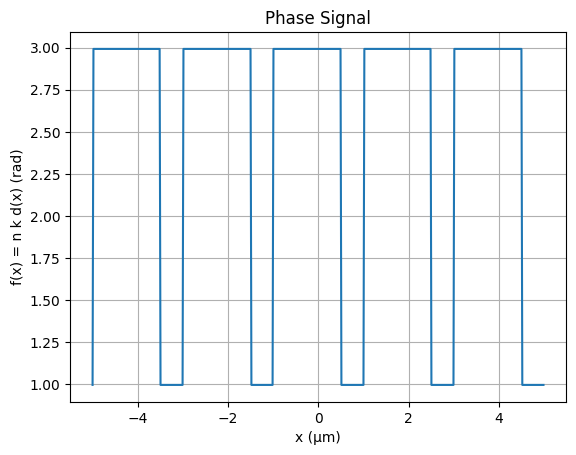

In [10]:
x = spatial_grid(L, Nx)

d = thickness_profile(x, Lambda, duty, d0, h)

f = phase_signal(d, n, lam)

plot_signal(x, f)

In [11]:
import numpy as np

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

In [12]:
phi, alpha = phi_from_f(f)

print("alpha =", alpha)
print("check normalization =", np.sum(phi**2))
print('phase =', phi)

alpha = 1274.58901945643
check normalization = 0.9999999999999999
phase = [0.02797271 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016
 0.04845016 0.04845016 0.04845016 0.04845016 0.04845016 0.02797271
 0.02797271 0.02797271 0.02797271 0.02797271 0.02797271

/tmp/ipykernel_210104/1324536694.py:28: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  print("Prepared statevector length:", len(sv))


Prepared statevector length: 512
Circuit depth: 1


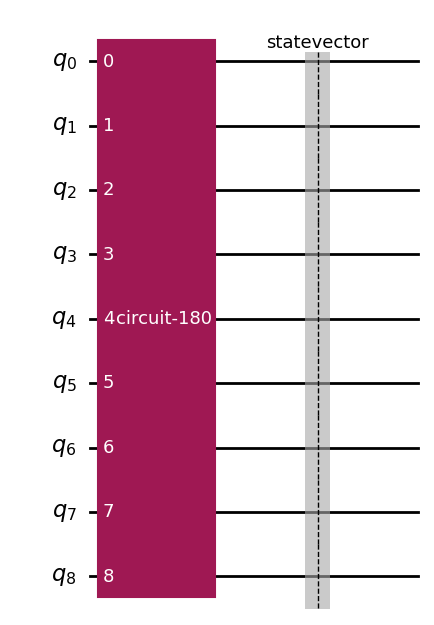

In [13]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState

# phi must have length 2^n
phi = np.asarray(phi, dtype=float)
N = len(phi)
n = int(np.log2(N))
assert 2**n == N, "len(phi) must be a power of 2 (2^n)."

number_of_layers = 2

# build MPS initializer for |phi>
phi_state = QuantumState.from_dense_data(data=phi, normalize=True)
U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=number_of_layers)

# single-register circuit
qc = QuantumCircuit(n, name="prep_phi")
qc.append(U_phi, range(n))

# (optional) simulate to confirm statevector
sim = AerSimulator(method="statevector")
qc.save_statevector()
res = sim.run(transpile(qc, sim)).result()
sv = res.get_statevector(qc)

print("Prepared statevector length:", len(sv))
print("Circuit depth:", qc.depth())
qc.draw("mpl")

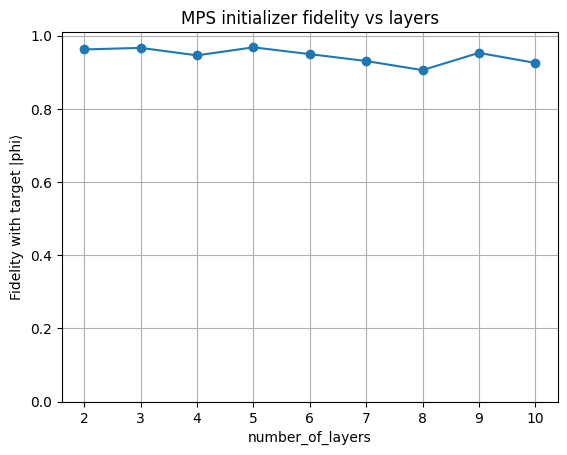

[(2, 0.96228347789901), (3, 0.9665410925940694), (4, 0.9460944107333671), (5, 0.968038134213729), (6, 0.9494916276595093), (7, 0.9306696490440377), (8, 0.9057701371445535), (9, 0.9529250836050398), (10, 0.9254953596789787)]


In [14]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity


phi = np.asarray(phi, dtype=float)
phi = phi / np.linalg.norm(phi)

N = len(phi)
n = int(np.log2(N))


# simulator
sim = AerSimulator(method="statevector")

# ---------------------------
# 1) Sweep layers and fidelity
# ---------------------------
layers_list = list(range(2, 11))
fidelities = []

for L in layers_list:
    # build initializer for this number of layers
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=L)

    # prepare circuit
    qc = QuantumCircuit(n)
    qc.append(U_phi, range(n))
    qc.save_statevector()

    # simulate
    result = sim.run(transpile(qc, sim)).result()
    prepared = np.array(result.get_statevector(qc), dtype=complex)

    # fidelity with target (pure state)
    F = state_fidelity(prepared, phi.astype(complex))
    fidelities.append(F)

# ---------------------------
# 2) Plot
# ---------------------------
plt.figure()
plt.plot(layers_list, fidelities, marker="o")
plt.xlabel("number_of_layers")
plt.ylabel("Fidelity with target |phi⟩")
plt.title("MPS initializer fidelity vs layers")
plt.grid(True)
plt.ylim(0, 1.01)
plt.show()

print(list(zip(layers_list, fidelities)))

Vector length N = 512
Qubits per register = 9
Total quantum qubits = 18

Example m = 50, delta = 0.00785
Fidelity = 1.000000
Circuit depth = 350


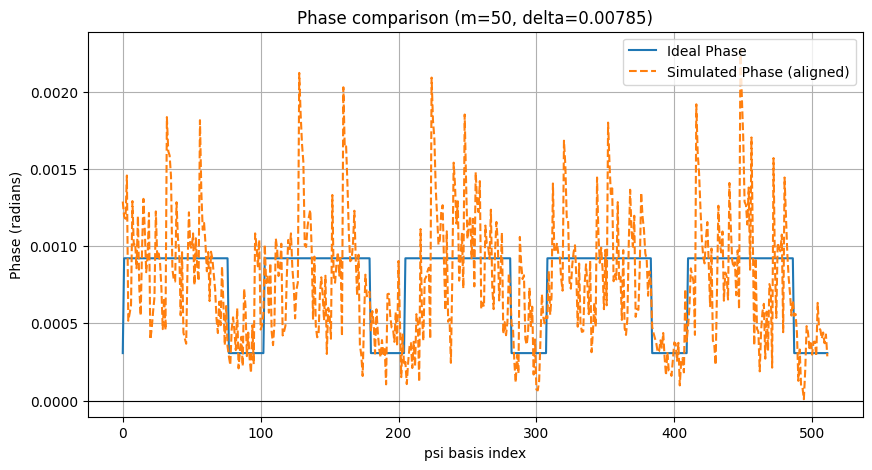

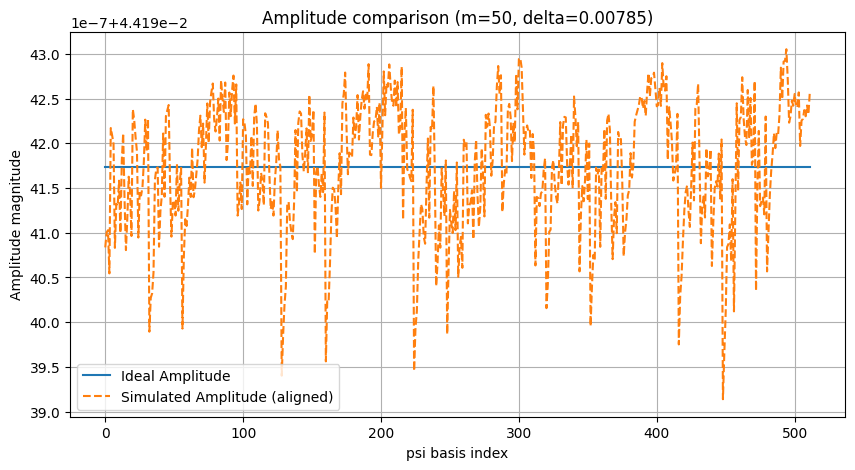

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import partial_trace, DensityMatrix, state_fidelity

# -------------------------------------------------
# Assume you already have f and phi_from_f(f) defined
# Example:
# phi, alpha = phi_from_f(f)
# -------------------------------------------------

# --- get phi from your signal pipeline ---
phi, alpha = phi_from_f(f)


# convert to numpy array
phi = np.asarray(phi, dtype=float)

# --- dimensions from phi ---
N = len(phi)
n = int(np.log2(N))

assert 2**n == N, "len(phi) must be a power of 2 (2^n)."

# -------------------------------------------------
# Define psi with the SAME length as phi
# You can choose any 512-entry vector you want.
# Here I use a simple ramp as a default example.
# -------------------------------------------------
psi = np.ones(N, dtype=float)

# If you prefer uniform psi instead, use:
# psi = np.ones(N, dtype=float)



print("Vector length N =", N)
print("Qubits per register =", n)
print("Total quantum qubits =", 2 * n)

number_of_layers = 4

# -------------------------------------------------
# Create normalized QuantumState objects
# -------------------------------------------------
psi_state = QuantumState.from_dense_data(data=psi, normalize=True)
phi_state = QuantumState.from_dense_data(data=phi, normalize=True)

# -------------------------------------------------
# Generate MPS initializer circuits
# -------------------------------------------------
U_psi = psi_state.generate_mps_initializer_circuit(number_of_layers=number_of_layers)
U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=number_of_layers)
U_phi_dagger = U_phi.inverse()

# -------------------------------------------------
# Protocol function
# -------------------------------------------------
def run_protocol(m, delta, return_state=False):
    psi_reg = QuantumRegister(n, name="psi")
    phi_reg = QuantumRegister(n, name="phi")
    creg = ClassicalRegister(n, name="c")
    qc = QuantumCircuit(psi_reg, phi_reg, creg)

    # initialize states
    qc.append(U_psi, psi_reg)
    qc.append(U_phi, phi_reg)

    # iterative protocol
    for k in range(1, m + 1):
        # CNOT flags
        for i in range(n):
            qc.cx(phi_reg[n - 1 - i], psi_reg[n - 1 - i], ctrl_state=0)

        # apply small phase
        qc.mcp(delta, psi_reg[0:-1], psi_reg[-1])

        # uncompute flags
        for i in range(n):
            qc.cx(phi_reg[i], psi_reg[i], ctrl_state=0)

        # uncompute phi, measure, reset
        qc.append(U_phi_dagger, phi_reg)
        qc.measure(phi_reg, creg)
        qc.reset(phi_reg)

        if k < m:
            qc.append(U_phi, phi_reg)

    # simulate
    sim = AerSimulator(method="statevector")
    qc.save_statevector()
    result = sim.run(transpile(qc, sim)).result()
    full_state = result.get_statevector(qc)

    # reduced density matrix for psi
    rho_psi = partial_trace(full_state, list(range(n, 2 * n)))

    # ideal target vector with programmable phase
    psi_vec = np.array(psi, dtype=complex) / np.linalg.norm(psi)
    phi_vec = np.array(phi, dtype=float) / np.linalg.norm(phi)

    phase_profile = np.exp(1j * delta * m * np.abs(phi_vec)**2)
    ideal_vec = psi_vec * phase_profile
    rho_ideal = DensityMatrix(ideal_vec)

    # fidelity
    fid = state_fidelity(rho_psi, rho_ideal)

    if return_state:
        return fid, rho_psi, ideal_vec, qc
    return fid

# -------------------------------------------------
# Example run
# -------------------------------------------------
m_example = 50
delta_example = np.pi / 400

fid_ex, rho_psi, ideal_vec, qc = run_protocol(
    m_example, delta_example, return_state=True
)

# Convert reduced state to statevector if pure enough
vec_sim = np.array(rho_psi.to_statevector())

# Align global phase
global_phase = np.angle(np.vdot(ideal_vec, vec_sim))
vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

# amplitudes and phases
amps_ideal = np.abs(ideal_vec)
amps_sim = np.abs(vec_sim_aligned)
phases_ideal = np.unwrap(np.angle(ideal_vec))
phases_sim = np.unwrap(np.angle(vec_sim_aligned))

print(f"\nExample m = {m_example}, delta = {delta_example:.5f}")
print(f"Fidelity = {fid_ex:.6f}")
print("Circuit depth =", qc.depth())



# -------------------------------------------------
# Phase comparison
# -------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(N), phases_ideal, label="Ideal Phase")
plt.plot(range(N), phases_sim, "--", label="Simulated Phase (aligned)")
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Phase (radians)")
plt.xlabel("psi basis index")
plt.title(f"Phase comparison (m={m_example}, delta={delta_example:.5f})")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------
# Amplitude comparison
# -------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(N), amps_ideal, label="Ideal Amplitude")
plt.plot(range(N), amps_sim, "--", label="Simulated Amplitude (aligned)")
plt.ylabel("Amplitude magnitude")
plt.xlabel("psi basis index")
plt.title(f"Amplitude comparison (m={m_example}, delta={delta_example:.5f})")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------
# Optional: fidelity vs m
# -------------------------------------------------
